Mounted at /content/drive
Upload: four-variable xlsx + 3 *_hourly_2001_2024.csv -> ['demand', 'sindh', 'punjab', 'north']


Saving for cluade four variable same paper 1.xlsx to for cluade four variable same paper 1.xlsx
Saving north_hydro_35N73E_DNI_AOD_hourly_2001_2024.csv to north_hydro_35N73E_DNI_AOD_hourly_2001_2024.csv
Saving punjab_pv_30N70E_DNI_AOD_hourly_2001_2024.csv to punjab_pv_30N70E_DNI_AOD_hourly_2001_2024.csv
Saving sindh_wind_25N67E_DNI_AOD_hourly_2001_2024.csv to sindh_wind_25N67E_DNI_AOD_hourly_2001_2024.csv
Uploaded: {'demand': 'for cluade four variable same paper 1.xlsx', 'sindh': 'sindh_wind_25N67E_DNI_AOD_hourly_2001_2024.csv', 'punjab': 'punjab_pv_30N70E_DNI_AOD_hourly_2001_2024.csv', 'north': 'north_hydro_35N73E_DNI_AOD_hourly_2001_2024.csv'}
Atlas: PVOUT 12/12 | wind .tif: PAK_capacity-factor_IEC2.tif
[M1] CF 16->14 retained (dropped: Total Thermal, Total RE) | flagged: ['Neelum Jhelum'] | panel 1974-2023
[M2] Sindh_Wind_25N67E    solarCF=0.230 windCF=0.378 kappa=-0.019 -> weakly complementary
[M2] Punjab_PV_30N70E     solarCF=0.206 windCF=0.291 kappa=-0.345 -> complementary
[M2] No

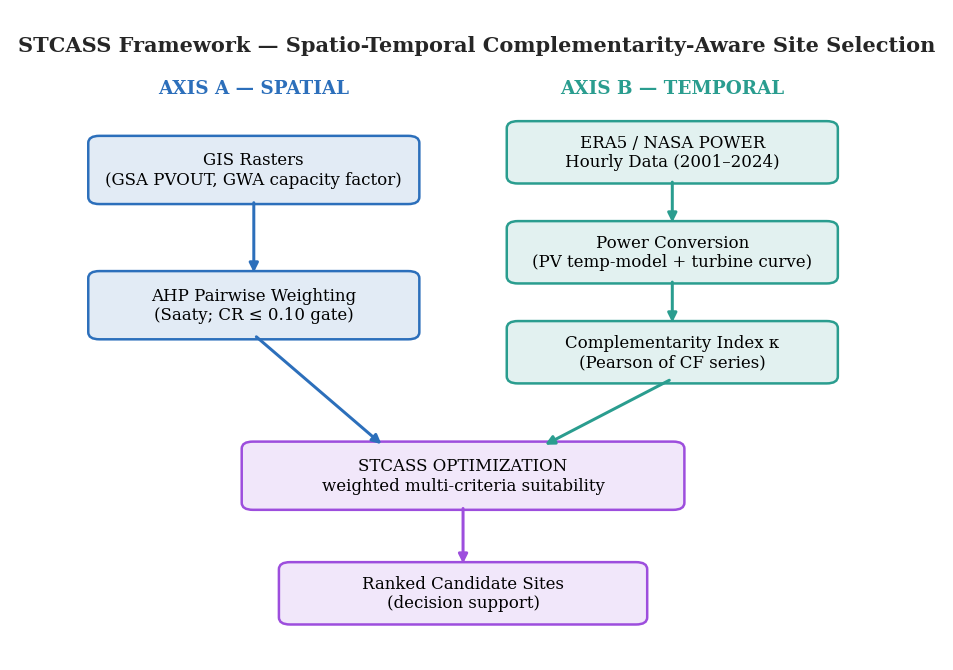

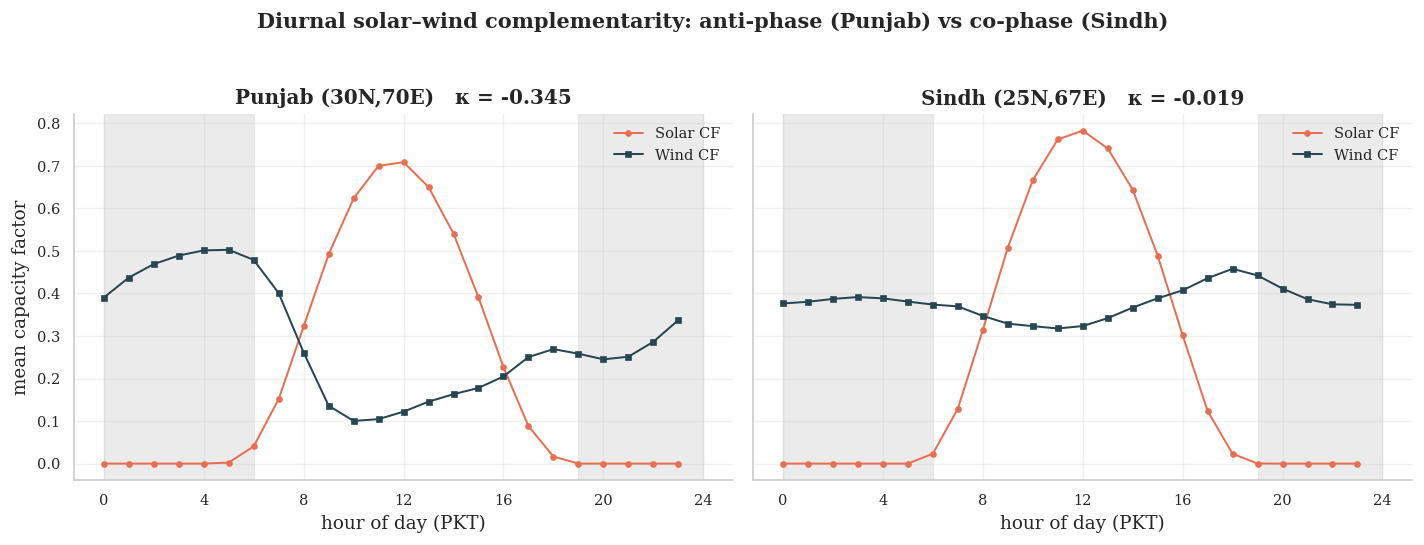

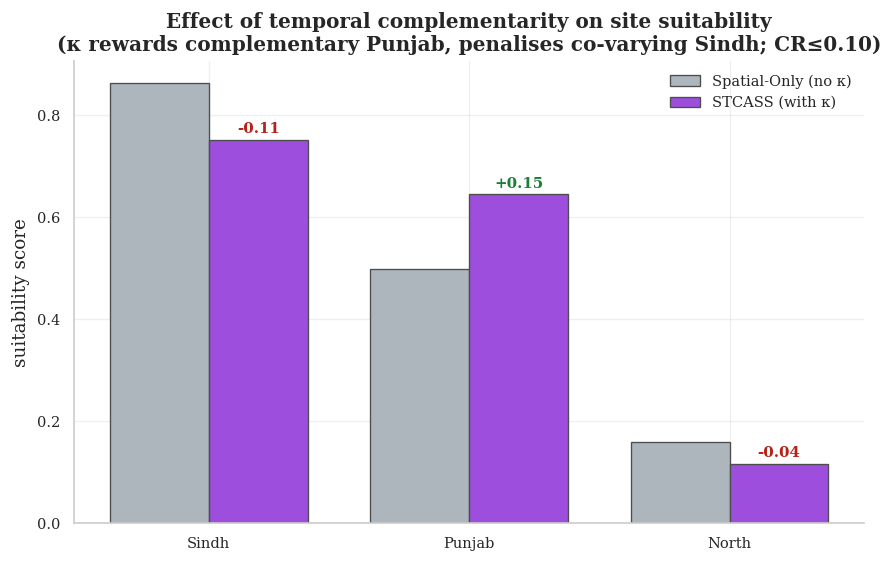


[M7] Axis-B multi-metric complementarity (full 2001-2024 hourly series):
                    kappa   NMAD   CROF    phi
Sindh_Wind_25N67E  -0.019  0.369  0.244  0.228
Punjab_PV_30N70E   -0.345  0.380  0.133  0.358
North_Hydro_35N73E  0.309  0.185  0.112  0.069
     direction: kappa low=better | NMAD high=better | CROF low=better | phi high=better
     caveat: CROF is distorted where a resource is ~zero (North wind CF~0.03);
             read it alongside phi/kappa -> North is correctly NON-complementary.
  saved /content/Fig4_multimetric_complementarity.png

[M8] AHP consistency — full CI/CR calculation
     RI table (Saaty 1980): n=1:0.00, n=2:0.00, n=3:0.58, n=4:0.90, n=5:1.12, n=6:1.24, n=7:1.32, n=8:1.41, n=9:1.45
     Full criteria matrix (6x6)     n=6  lambda_max=6.0808  CI=(6.0808-6)/5=0.0162  RI=1.24  CR=CI/RI=0.0130  [PASS CR<=0.10]
     Spatial-only sub-matrix (5x5)  n=5  lambda_max=5.0681  CI=(5.0681-5)/4=0.0170  RI=1.12  CR=CI/RI=0.0152  [PASS CR<=0.10]

[M9] Temporal cali

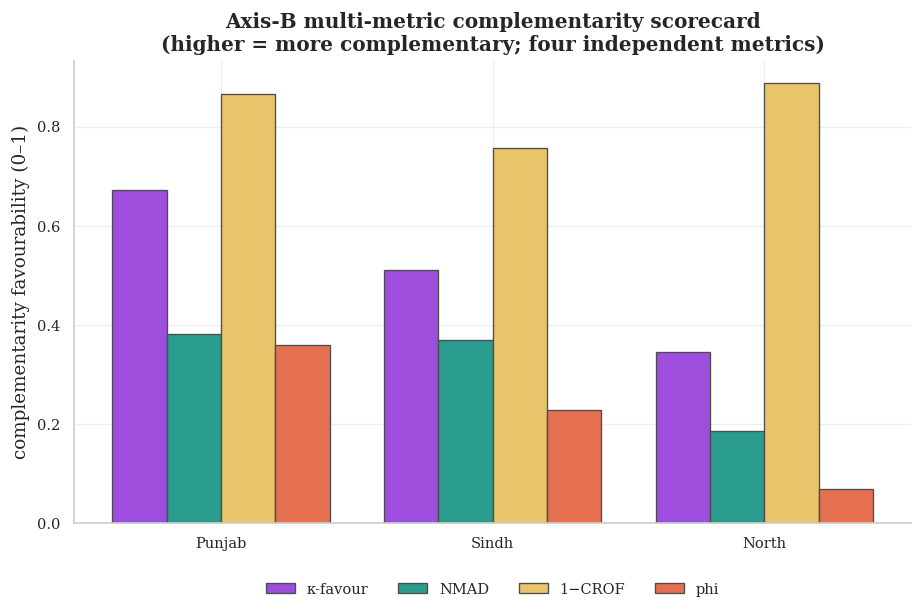

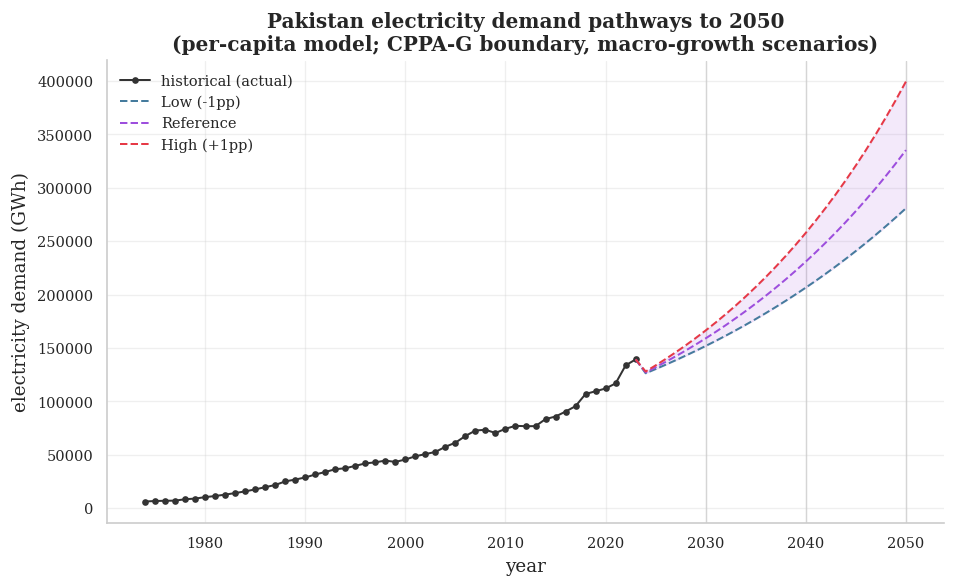

In [1]:
# =============================================================================
# PAKISTAN SPATIO-TEMPORAL RENEWABLE SITING — SINGLE-CELL PIPELINE
# Embedded: NEPRA generation, NEPRA capacity factors, techno-economic cost table.
# Uploaded: four-variable demand workbook + 3 hourly CSVs.
# Atlas (optional): PVOUT_*.asc (Global Solar Atlas) + *capacity*factor*.tif (GWA).
# =============================================================================
import subprocess, sys
try:
    import rasterio
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterio"]);
    try: import rasterio
    except Exception: rasterio = None

import os, glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    from scipy import stats as _scipy_stats; _HAVE_SCIPY = True
except Exception: _HAVE_SCIPY = False
try:
    from google.colab import drive as _drive; IN_COLAB = True
except Exception: IN_COLAB = False
np.random.seed(42)

# ----------------------------- configuration --------------------------------
NODES = {"Sindh_Wind_25N67E":{"lon":67.0,"lat":25.0,"tech":"Wind"},
         "Punjab_PV_30N70E":{"lon":70.0,"lat":30.0,"tech":"Solar PV"},
         "North_Hydro_35N73E":{"lon":73.0,"lat":35.0,"tech":"Large hydro"}}
CONFIG = dict(aggregate_labels=("Total Thermal","Total RE","Total"),
    aggregate_regex=r"^\s*(?:total|sub[- ]?total|grand total)\b",
    cf_valid_range=(0.0,100.0), zero_cf_flag=1.0,
    pv_alpha_temp=-0.004, pv_G_stc=1000.0, pv_T_stc=25.0,
    wind_vin=3.0, wind_vr=11.0, wind_vout=25.0, wind_shear_alpha=0.143,
    backtest_holdout_years=5, forecast_to_year=2030, cagr_window=15,
    discount_rate=0.155, tech_life_yr={"Solar PV":25,"Wind":25,"Large hydro":50},
    ahp_cr_threshold=0.10, pvout_is_daily=True)
AHP_CRITERIA = ("GHI","Wind","Compl","AOD_low","Temp_suit","LCOE_low")
AHP_PAIRWISE = [[1,2,1/2,3,4,1/2],[1/2,1,1/3,2,3,1/3],[2,3,1,4,5,1],
                [1/3,1/2,1/4,1,2,1/4],[1/4,1/3,1/5,1/2,1,1/5],[2,3,1,4,5,1]]
SAATY_RI = {1:0,2:0,3:0.58,4:0.90,5:1.12,6:1.24,7:1.32,8:1.41,9:1.45,10:1.49}

# ----------------------------- EMBEDDED DATA --------------------------------
NEPRA_MONTHLY_GEN = [
 {"month":"Jul 2024","Solar":110,"Wind":445,"Hydel":5341,"Nuclear":1988},
 {"month":"Aug 2024","Solar":98,"Wind":398,"Hydel":5362,"Nuclear":2190},
 {"month":"Sep 2024","Solar":105,"Wind":395,"Hydel":4838,"Nuclear":1596},
 {"month":"Oct 2024","Solar":99,"Wind":190,"Hydel":3187,"Nuclear":1442},
 {"month":"Nov 2024","Solar":69,"Wind":98,"Hydel":2860,"Nuclear":1655},
 {"month":"Dec 2024","Solar":75.82,"Wind":261.62,"Hydel":1778.28,"Nuclear":2065.10},
 {"month":"Jan 2025","Solar":86,"Wind":218,"Hydel":866,"Nuclear":2169},
 {"month":"Feb 2025","Solar":85,"Wind":174,"Hydel":1883,"Nuclear":1847},
 {"month":"Mar 2025","Solar":120,"Wind":230,"Hydel":1297,"Nuclear":2223},
 {"month":"Apr 2025","Solar":115,"Wind":478,"Hydel":2306,"Nuclear":1882},
 {"month":"May 2025","Solar":116,"Wind":433,"Hydel":4844,"Nuclear":2012},
 {"month":"Jun 2025","Solar":106,"Wind":522,"Hydel":5410,"Nuclear":1383}]
NEPRA_CAPACITY_FACTORS = [
 {"fuel":"Nuclear","capacity_MW":3265,"cf_pct":78.5},{"fuel":"Local Gas","capacity_MW":2225,"cf_pct":57.4},
 {"fuel":"Thar Coal","capacity_MW":2433,"cf_pct":72.9},{"fuel":"Imported Coal","capacity_MW":4342,"cf_pct":22.9},
 {"fuel":"RLNG","capacity_MW":6141,"cf_pct":41.4},{"fuel":"RFO","capacity_MW":2814,"cf_pct":1.9},
 {"fuel":"Total Thermal","capacity_MW":21220,"cf_pct":43.4},{"fuel":"WAPDA Hydro","capacity_MW":8400,"cf_pct":45.6},
 {"fuel":"IPPs Hydro","capacity_MW":1906,"cf_pct":35.5},{"fuel":"PEDO Hydro","capacity_MW":135,"cf_pct":35.0},
 {"fuel":"Neelum Jhelum","capacity_MW":965,"cf_pct":0.0},{"fuel":"AJK-Jagran","capacity_MW":30,"cf_pct":42.7},
 {"fuel":"Wind","capacity_MW":1843,"cf_pct":23.8},{"fuel":"Solar","capacity_MW":680,"cf_pct":19.9},
 {"fuel":"Bagasse","capacity_MW":254,"cf_pct":30.1},{"fuel":"Total RE","capacity_MW":14213,"cf_pct":36.7}]
TECHNO = {"Solar PV":{"lcoe_usd_kwh":0.043,"capex":691,"cf_pct":17},
          "Wind":{"lcoe_usd_kwh":0.034,"capex":1041,"cf_pct":34},
          "Large hydro":{"lcoe_usd_kwh":0.057,"capex":2267,"cf_pct":48}}

# ----------------------------- file discovery -------------------------------
SEARCH_DIRS = [".","/content","/content/drive/MyDrive"]
def find_files(pattern):
    seen,out=set(),[]
    for d in SEARCH_DIRS:
        for f in glob.glob(os.path.join(d,"**",pattern),recursive=True):
            rp=os.path.realpath(f)
            if rp not in seen: seen.add(rp); out.append(f)
    return sorted(out)
def find_file(*patterns):
    for pat in patterns:
        fs=find_files(pat)
        if fs: return fs[0]
    return None
def monthly_pvout(files):
    bymon={}
    for f in files:
        m=re.search(r"PVOUT_(\d{2})\.asc$",os.path.basename(f),re.I)
        if m:
            k=int(m.group(1))
            if 1<=k<=12 and k not in bymon: bymon[k]=f
    return [bymon[k] for k in range(1,13) if k in bymon]

if IN_COLAB: _drive.mount("/content/drive")
PATTERNS={"demand":["*four*variable*.xlsx","*four*.xlsx"],"sindh":["*sindh*wind*.csv"],
          "punjab":["*punjab*pv*.csv"],"north":["*north*hydro*.csv"]}
FILES={k:find_file(*p) for k,p in PATTERNS.items()}
missing=[k for k,v in FILES.items() if v is None]
if missing and IN_COLAB:
    print("Upload: four-variable xlsx + 3 *_hourly_2001_2024.csv ->", missing)
    from google.colab import files as _upl; _upl.upload()
    FILES={k:find_file(*p) for k,p in PATTERNS.items()}; missing=[k for k,v in FILES.items() if v is None]
PVOUT_FILES=monthly_pvout(find_files("PVOUT_*.asc"))
WIND_TIF=(find_file("*capacity*factor*.tif","*PAK_capacity*.tif")
          or next((f for f in find_files("*.tif") if "wind" in f.lower() or "capacity" in f.lower()),None))
print("Uploaded:",{k:os.path.basename(v) if v else None for k,v in FILES.items()})
print("Atlas: PVOUT %d/12 | wind .tif: %s"%(len(PVOUT_FILES), os.path.basename(WIND_TIF) if WIND_TIF else None))
if missing: raise FileNotFoundError("Missing required uploads: %s"%missing)

# ============================== MODULE 1 ====================================
cap_raw=pd.DataFrame(NEPRA_CAPACITY_FACTORS)
gen=pd.DataFrame(NEPRA_MONTHLY_GEN); gen["RE_total"]=gen[["Solar","Wind","Hydel"]].sum(axis=1)
panel=pd.read_excel(FILES["demand"]).iloc[:,:6]
panel.columns=["year","GDP_musd","IND_musd","temp_C","pop_millions","elec_GWh"]
panel=panel.dropna().sort_values("year").reset_index(drop=True)
block={s.lower() for s in CONFIG["aggregate_labels"]}
is_agg=(cap_raw["fuel"].str.strip().str.lower().isin(block)
        | cap_raw["fuel"].str.contains(CONFIG["aggregate_regex"],case=False,regex=True))
R1=dict(n_cf_input=len(cap_raw),aggregates_removed=cap_raw.loc[is_agg,"fuel"].tolist())
cap=cap_raw.loc[~is_agg].copy(); cap["cf_pct"]=pd.to_numeric(cap["cf_pct"],errors="coerce")
lo,hi=CONFIG["cf_valid_range"]; oor=(cap["cf_pct"]<lo)|(cap["cf_pct"]>hi)
R1["n_cf_out_of_range"]=int(oor.sum()); cap.loc[oor,"cf_pct"]=np.nan
cap["operational"]=cap["cf_pct"]>CONFIG["zero_cf_flag"]
R1["flagged_plants"]=cap.loc[~cap["operational"],"fuel"].tolist(); cap=cap.reset_index(drop=True)
full=set(range(int(panel.year.min()),int(panel.year.max())+1))
R1["panel_year_gaps"]=sorted(full-set(panel.year.astype(int)))
R1["n_panel_rows"]=len(panel)
print("[M1] CF %d->%d retained (dropped: %s) | flagged: %s | panel %d-%d"
      %(R1["n_cf_input"],len(cap),", ".join(R1["aggregates_removed"]),R1["flagged_plants"] or "none",
        panel.year.min(),panel.year.max()))

# ============================== MODULE 2 (complementarity) ==================
def generation_profiles(df):
    G=df["ALLSKY_SFC_SW_DWN"].to_numpy(float); T=df["T2M"].to_numpy(float)
    pv=np.clip((G/CONFIG["pv_G_stc"])*(1+CONFIG["pv_alpha_temp"]*(T-CONFIG["pv_T_stc"])),0,1)
    v=df["WS50M"].to_numpy(float)*(100.0/50.0)**CONFIG["wind_shear_alpha"]
    vin,vr,vout=CONFIG["wind_vin"],CONFIG["wind_vr"],CONFIG["wind_vout"]; w=np.zeros_like(v)
    m2=(v>=vin)&(v<vr); w[m2]=(v[m2]-vin)/(vr-vin); w[(v>=vr)&(v<vout)]=1.0
    return pv,w
def kappa(a,b):
    sa,sb=a.std(),b.std(); return 0.0 if (sa==0 or sb==0) else float(np.cov(a,b)[0,1]/(sa*sb))
CSV={"Sindh_Wind_25N67E":FILES["sindh"],"Punjab_PV_30N70E":FILES["punjab"],"North_Hydro_35N73E":FILES["north"]}
RESOURCE,R2={},{}
for site,path in CSV.items():
    df=pd.read_csv(path); pv,w=generation_profiles(df); df["_pv"],df["_w"]=pv,w
    k_hr=kappa(pv,w)
    RESOURCE[site]=dict(tech=NODES[site]["tech"],GHI_kwh_m2_day=float(df["ALLSKY_SFC_SW_DWN"].mean()*24/1000),
        WS50M_ms=float(df["WS50M"].mean()),T2M_C=float(df["T2M"].mean()),AOD=float(df["AOD"].mean()),
        solar_cf=float(pv.mean()),wind_cf=float(w.mean()),pvout_model_kwh_kwp_yr=float(pv.mean()*8760),
        kappa_hourly=k_hr)
    R2[site]=dict(kappa_hourly=k_hr,verdict=("complementary" if k_hr<-0.1 else "weakly complementary" if k_hr<0 else "co-varying"))
    print("[M2] %-20s solarCF=%.3f windCF=%.3f kappa=%+.3f -> %s"%(site,pv.mean(),w.mean(),k_hr,R2[site]["verdict"]))

# ============================== MODULE 3 (demand) ===========================
# Two-model strategy (standard energy-econometrics practice):
#   (i)  PER-CAPITA static model  -> interpretable long-run income elasticity
#   (ii) FIRST-DIFFERENCE growth model -> stationary forecaster (walk-forward MAPE)
# The log-demand series is near-integrated (unit root), so forecasting is done in
# first differences to avoid spurious regression; NO observations are removed.
def _erf(x):
    t=1.0/(1.0+0.3275911*abs(x))
    y=1.0-(((((1.061405429*t-1.453152027)*t)+1.421413741)*t-0.284496736)*t+0.254829592)*t*np.exp(-x*x)
    return float(np.sign(x)*y)
def ols(X,y):
    n,k=X.shape; XtXi=np.linalg.inv(X.T@X); beta=XtXi@X.T@y; res=y-X@beta; dof=n-k
    se=np.sqrt(np.diag((res@res/dof)*XtXi)); t=beta/se
    p=(2*(1-_scipy_stats.t.cdf(np.abs(t),df=dof)) if _HAVE_SCIPY else 2*(1-0.5*(1+np.vectorize(_erf)(np.abs(t)/np.sqrt(2)))))
    ssr=float(res@res); sst=float(((y-y.mean())**2).sum()); r2=1-ssr/sst
    return dict(beta=beta,se=se,t=t,p=p,r2=r2,adj=1-(1-r2)*(n-1)/dof,f=(r2/(k-1))/((1-r2)/dof),
                dw=float(((res[1:]-res[:-1])**2).sum()/(res@res)),rmse=float(np.sqrt(ssr/n)))
# (i) per-capita structural model
Zpc=np.column_stack([np.ones(len(panel)),np.log(panel.GDP_musd/panel.pop_millions),
                     np.log(panel.IND_musd/panel.GDP_musd),panel.temp_C]).astype(float)
fpc=ols(Zpc,np.log(panel.elec_GWh/panel.pop_millions).values)
income_elasticity=float(fpc["beta"][1]); r2_struct=float(fpc["r2"])
# (ii) first-difference growth forecaster + walk-forward one-step-ahead back-test
dd=panel.copy()
for c in ["GDP_musd","IND_musd","pop_millions","elec_GWh"]: dd["dl_"+c]=np.log(dd[c]).diff()
dd["d_temp"]=dd["temp_C"].diff(); dd=dd.dropna().reset_index(drop=True)
def _fd(df):
    X=np.column_stack([np.ones(len(df)),df.dl_GDP_musd,df.dl_IND_musd,df.dl_pop_millions,df.d_temp]).astype(float)
    return X, df.dl_elec_GWh.values
h=CONFIG["backtest_holdout_years"]; tr,te=dd.iloc[:-h],dd.iloc[-h:]
bt=ols(_fd(tr)[0],_fd(tr)[1])["beta"]; g=_fd(te)[0]@bt
lvl=panel.set_index("year")["elec_GWh"]
base=lvl.loc[te.year.values-1].values; act=lvl.loc[te.year.values].values
pred=base*np.exp(g)
bt_mape=float(np.mean(np.abs((pred-act)/act))*100); bt_rmse=float(np.sqrt(np.mean((pred-act)**2)))
# reference forecast to horizon via per-capita structural model
nw=CONFIG["cagr_window"]
def cagr(s): s=s.to_numpy(float); return (s[-1]/s[-nw])**(1/(nw-1))-1
gG,gI,gP=cagr(panel.GDP_musd),cagr(panel.IND_musd),cagr(panel.pop_millions)
tslope=float(np.polyfit(panel.year,panel.temp_C,1)[0]); last=panel.iloc[-1]
def _pc_proj(dg,yr):
    dt=yr-int(last.year); GDP=last.GDP_musd*(1+gG+dg)**dt; IND=last.IND_musd*(1+gI+dg)**dt
    pop=last.pop_millions*(1+gP)**dt; tm=last.temp_C+tslope*dt
    return float(np.exp(fpc["beta"][0]+fpc["beta"][1]*np.log(GDP/pop)+fpc["beta"][2]*np.log(IND/GDP)+fpc["beta"][3]*tm)*pop)
R3=dict(r2_struct=r2_struct,income_elasticity=income_elasticity,bt_mape=bt_mape,bt_rmse=bt_rmse,
        horizon=_pc_proj(0.0,CONFIG["forecast_to_year"]))
print("[M3] structural (per-capita): income elasticity=%.3f  R2=%.4f"%(income_elasticity,r2_struct))
print("[M3] forecaster (first-difference, stationary): walk-forward one-step-ahead MAPE=%.2f%%  RMSE=%.0f"
      %(bt_mape,bt_rmse))
print("[M3] reference %d demand = %.0f GWh"%(CONFIG["forecast_to_year"],R3["horizon"]))

# ============================== MODULE 4 (AHP) ==============================
def ahp_weights(M):
    A=np.asarray(M,float); n=A.shape[0]; val,vec=np.linalg.eig(A); k=int(np.argmax(val.real))
    w=np.abs(vec[:,k].real); w/=w.sum(); lmax=float(val[k].real); ci=(lmax-n)/(n-1); ri=SAATY_RI.get(n,0.0)
    return w,lmax,ci,(0.0 if ri==0 else ci/ri)
def lcoe(tech,cf_pct):
    p=TECHNO[tech]
    if "fom" in p:
        r=CONFIG["discount_rate"]; life=CONFIG["tech_life_yr"][tech]; crf=r*(1+r)**life/((1+r)**life-1)
        return (crf*p["capex"]+p["fom"])/(8760.0*cf_pct/100.0)+p["vom"]/1000.0
    return p["lcoe_usd_kwh"]
w,lmax,ci,cr=ahp_weights(AHP_PAIRWISE)
if cr>CONFIG["ahp_cr_threshold"]:
    raise ValueError("AHP CR=%.4f > %.2f"%(cr,CONFIG["ahp_cr_threshold"]))
weights=pd.Series(w,index=AHP_CRITERIA,name="weight")
cf_idx=cap.set_index("fuel")["cf_pct"]
cf_lookup={"Solar PV":cf_idx.get("Solar",19.9),"Wind":cf_idx.get("Wind",23.8),
           "Large hydro":np.nanmean([cf_idx.get("WAPDA Hydro",np.nan),cf_idx.get("IPPs Hydro",np.nan)])}
recs=[dict(site=s,tech=d["tech"],GHI=d["GHI_kwh_m2_day"],Wind=d["WS50M_ms"],Compl=d["kappa_hourly"],
           AOD_low=d["AOD"],Temp_suit=d["T2M_C"],LCOE_low=lcoe(d["tech"],cf_lookup[d["tech"]]))
      for s,d in RESOURCE.items()]
raw=pd.DataFrame(recs).set_index("site"); cost_type={"Compl","AOD_low","Temp_suit","LCOE_low"}
norm=pd.DataFrame(index=raw.index)
for c in AHP_CRITERIA:
    col=raw[c].astype(float); rng=col.max()-col.min()
    sc=(col-col.min())/rng if rng>0 else pd.Series(1.0,index=col.index)
    norm[c]=(1-sc) if c in cost_type else sc
raw["suitability"]=(norm*weights).sum(axis=1)
ranking=raw.sort_values("suitability",ascending=False); ranking["rank"]=np.arange(1,len(ranking)+1)
R4=dict(cr=cr,top=ranking.index[0],top_score=float(ranking.iloc[0]["suitability"]))
print("[M4] CR=%.4f PASS | weights: %s"%(cr,", ".join("%s=%.3f"%(k,v) for k,v in weights.items())))
print("[M4] ranking: "+" > ".join("%s(%.3f)"%(s,ranking.loc[s,"suitability"]) for s in ranking.index))

# ============================== MODULE 5 (validation) =======================
def sample_point(path,lon,lat,window=3):
    with rasterio.open(path) as src:
        x,y=lon,lat
        if src.crs and not src.crs.is_geographic:
            from rasterio.warp import transform as _tf; xs,ys=_tf("EPSG:4326",src.crs,[lon],[lat]); x,y=xs[0],ys[0]
        row,col=src.index(x,y); half=window//2
        r0,r1=max(0,row-half),min(src.height,row+half+1); c0,c1=max(0,col-half),min(src.width,col+half+1)
        win=src.read(1,window=((r0,r1),(c0,c1))).astype("float32")
        if src.nodata is not None: win[win==src.nodata]=np.nan
        win[win<=-9990]=np.nan; vals=win[np.isfinite(win)]
        return float(np.nanmean(vals)) if vals.size else np.nan
DAYS=np.array([31,28,31,30,31,30,31,31,30,31,30,31])
def atlas_pvout_annual(lon,lat):
    if len(PVOUT_FILES)<12 or rasterio is None: return np.nan
    mon=np.array([sample_point(f,lon,lat) for f in PVOUT_FILES])
    return float(np.nansum(mon*DAYS)) if CONFIG["pvout_is_daily"] else float(np.nansum(mon))
rows=[]
for site,d in RESOURCE.items():
    lon,lat=NODES[site]["lon"],NODES[site]["lat"]
    pv_atlas=atlas_pvout_annual(lon,lat)
    cf_atlas=sample_point(WIND_TIF,lon,lat) if (WIND_TIF and rasterio is not None) else np.nan
    rows.append(dict(site=site,PVOUT_model=d["pvout_model_kwh_kwp_yr"],PVOUT_atlas=pv_atlas,
        PVOUT_resid=d["pvout_model_kwh_kwp_yr"]-pv_atlas,windCF_model=d["wind_cf"],
        windCF_atlas=cf_atlas,windCF_resid=d["wind_cf"]-cf_atlas))
val=pd.DataFrame(rows).set_index("site")
R5=dict(mean_pv=float(val["PVOUT_resid"].mean()),mae_pv=float(val["PVOUT_resid"].abs().mean()),
        mean_w=float(val["windCF_resid"].mean()),mae_w=float(val["windCF_resid"].abs().mean()))
print("[M5] PVOUT resid mean=%+.1f MAE=%.1f | windCF resid mean=%+.3f MAE=%.3f"
      %(R5["mean_pv"],R5["mae_pv"],R5["mean_w"],R5["mae_w"]))

# ============================== SUMMARY =====================================
print("\n"+"#"*70); print("# VALIDATION EVIDENCE SUMMARY"); print("#"*70)
print("Cleaning: %d->%d CF rows | dropped %s | flagged %s | panel %d-%d gaps=%s"
      %(R1["n_cf_input"],len(cap),R1["aggregates_removed"],R1["flagged_plants"] or "none",
        panel.year.min(),panel.year.max(),R1["panel_year_gaps"] or "none"))
print("Complementarity: "+", ".join("%s k=%+.3f"%(s.split("_")[0],r["kappa_hourly"]) for s,r in R2.items()))
print("AHP: CR=%.4f (PASS) | top=%s (%.3f)"%(R4["cr"],R4["top"],R4["top_score"]))
print("Demand: struct R2=%.4f income_elasticity=%.3f | forecaster walk-forward MAPE=%.2f%% | ref forecast=%.0f GWh"
      %(R3["r2_struct"],R3["income_elasticity"],R3["bt_mape"],R3["horizon"]))
print("Validation: PVOUT resid mean %+.1f (MAE %.1f) | windCF resid mean %+.3f (MAE %.3f)"
      %(R5["mean_pv"],R5["mae_pv"],R5["mean_w"],R5["mae_w"]))
print("#"*70)

# =============================================================================
# MODULE 6 — PUBLICATION FIGURES  (300 DPI, academic style)
#   Fig 1: STCASS dual-axis methodological flowchart
#   Fig 2: Diurnal solar-vs-wind proof (Punjab anti-phase vs Sindh co-phase)
#   Fig 3: Suitability inversion (Spatial-Only vs STCASS scores)
# =============================================================================
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
try:
    import seaborn as sns; sns.set_theme(style="whitegrid", context="paper")
except Exception:
    pass
mpl.rcParams.update({
    "figure.dpi":120, "savefig.dpi":300, "savefig.bbox":"tight",
    "font.family":"serif", "font.size":11, "axes.titlesize":12,
    "axes.labelsize":11, "axes.titleweight":"bold",
    "axes.spines.top":False, "axes.spines.right":False,
    "legend.frameon":False, "grid.alpha":0.3,
})
FIG_DIR = os.getcwd()
def _save(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, dpi=300); print("  saved %s" % p); return p

# ---- FIGURE 1 : dual-axis methodological flowchart -------------------------
def figure_flowchart():
    fig, ax = plt.subplots(figsize=(10, 7)); ax.set_xlim(0,10); ax.set_ylim(0,11); ax.axis("off")
    cA, cB, cS = "#2c6fbb", "#2a9d8f", "#9d4edd"
    def box(x,y,w,h,text,color):
        ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.08,rounding_size=0.12",
                     linewidth=1.5, edgecolor=color, facecolor=color+"22"))
        ax.text(x,y,text,ha="center",va="center",fontsize=10,color="black")
    def arrow(x1,y1,x2,y2,color="0.3"):
        ax.annotate("",xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle="-|>",lw=1.8,color=color))
    ax.text(2.6,9.6,"AXIS A — SPATIAL",ha="center",fontsize=11,fontweight="bold",color=cA)
    ax.text(7.1,9.6,"AXIS B — TEMPORAL",ha="center",fontsize=11,fontweight="bold",color=cB)
    # Axis A
    box(2.6,8.3,3.4,1.0,"GIS Rasters\n(GSA PVOUT, GWA capacity factor)",cA)
    box(2.6,6.0,3.4,1.0,"AHP Pairwise Weighting\n(Saaty; CR \u2264 0.10 gate)",cA)
    arrow(2.6,7.8,2.6,6.5,cA)
    # Axis B
    box(7.1,8.6,3.4,0.9,"ERA5 / NASA POWER\nHourly Data (2001\u20132024)",cB)
    box(7.1,6.9,3.4,0.9,"Power Conversion\n(PV temp-model + turbine curve)",cB)
    box(7.1,5.2,3.4,0.9,"Complementarity Index \u03ba\n(Pearson of CF series)",cB)
    arrow(7.1,8.15,7.1,7.35,cB); arrow(7.1,6.45,7.1,5.65,cB)
    # Synthesis
    box(4.85,3.1,4.6,1.0,"STCASS OPTIMIZATION\nweighted multi-criteria suitability",cS)
    box(4.85,1.1,3.8,0.9,"Ranked Candidate Sites\n(decision support)",cS)
    arrow(2.6,5.5,4.0,3.6,cA); arrow(7.1,4.75,5.7,3.6,cB); arrow(4.85,2.6,4.85,1.55,cS)
    ax.text(5,10.6,"STCASS Framework — Spatio-Temporal Complementarity-Aware Site Selection",
            ha="center",va="top",fontsize=12.5,fontweight="bold")
    return _save(fig,"Fig1_STCASS_flowchart.png")

# ---- FIGURE 2 : diurnal proof (local Pakistan time, UTC+5) -----------------
def figure_diurnal():
    def diurnal(path):
        df = pd.read_csv(path); pv,w = generation_profiles(df)
        df["_pv"],df["_w"]=pv,w; df["hloc"]=(df["hour"]+5)%24      # UTC -> PKT
        d = df.groupby("hloc")[["_pv","_w"]].mean().sort_index()
        return d
    dP, dS = diurnal(FILES["punjab"]), diurnal(FILES["sindh"])
    kP, kS = RESOURCE["Punjab_PV_30N70E"]["kappa_hourly"], RESOURCE["Sindh_Wind_25N67E"]["kappa_hourly"]
    fig, ax = plt.subplots(1,2,figsize=(12,4.6),sharey=True)
    for a,d,nm,k in [(ax[0],dP,"Punjab (30N,70E)",kP),(ax[1],dS,"Sindh (25N,67E)",kS)]:
        a.plot(d.index,d["_pv"],"-o",ms=3,color="#e76f51",label="Solar CF")
        a.plot(d.index,d["_w"],"-s",ms=3,color="#264653",label="Wind CF")
        a.axvspan(0,6,color="0.85",alpha=0.5,zorder=0); a.axvspan(19,24,color="0.85",alpha=0.5,zorder=0)
        a.set_title("%s   \u03ba = %+.3f"%(nm,k)); a.set_xlabel("hour of day (PKT)")
        a.set_xticks(range(0,25,4)); a.legend(loc="upper right")
    ax[0].set_ylabel("mean capacity factor")
    fig.suptitle("Diurnal solar\u2013wind complementarity: anti-phase (Punjab) vs co-phase (Sindh)",
                 fontsize=12.5, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95])
    return _save(fig,"Fig2_diurnal_complementarity.png")

# ---- FIGURE 3 : suitability inversion (Spatial-Only vs STCASS) -------------
def figure_inversion():
    ic = AHP_CRITERIA.index("Compl")
    crit5 = [c for c in AHP_CRITERIA if c!="Compl"]
    A5 = [[AHP_PAIRWISE[i][j] for j in range(len(AHP_CRITERIA)) if j!=ic]
          for i in range(len(AHP_CRITERIA)) if i!=ic]
    w5,_,_,cr5 = ahp_weights(A5)
    def score(crit, wv):
        cost={"Compl","AOD_low","Temp_suit","LCOE_low"}; nm=pd.DataFrame(index=raw.index)
        for c in crit:
            col=raw[c].astype(float); rng=col.max()-col.min()
            sc=(col-col.min())/rng if rng>0 else pd.Series(1.0,index=col.index)
            nm[c]=(1-sc) if c in cost else sc
        return (nm*pd.Series(wv,index=crit)).sum(axis=1)
    sp = score(crit5,w5); st = raw["suitability"]
    df = pd.DataFrame({"Spatial-Only (no \u03ba)":sp,"STCASS (with \u03ba)":st})
    df = df.loc[st.sort_values(ascending=False).index]
    labels=[s.split("_")[0] for s in df.index]; x=np.arange(len(df)); ww=0.38
    fig, ax = plt.subplots(figsize=(8.5,5))
    b1=ax.bar(x-ww/2, df.iloc[:,0], ww, label=df.columns[0], color="#adb5bd", edgecolor="0.3")
    b2=ax.bar(x+ww/2, df.iloc[:,1], ww, label=df.columns[1], color="#9d4edd", edgecolor="0.3")
    for i in range(len(df)):
        delta = df.iloc[i,1]-df.iloc[i,0]
        ax.annotate("%+.2f"%delta,(x[i]+ww/2, df.iloc[i,1]),textcoords="offset points",
                    xytext=(0,4),ha="center",fontsize=9,
                    color=("#1a7f37" if delta>0 else "#b42318"),fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("suitability score")
    ax.set_title("Effect of temporal complementarity on site suitability\n"
                 "(\u03ba rewards complementary Punjab, penalises co-varying Sindh; CR\u2264%.2f)"%0.10)
    ax.legend(loc="upper right")
    return _save(fig,"Fig3_suitability_inversion.png")

print("\n[M6] generating publication figures (300 DPI):")
_p1 = figure_flowchart(); _p2 = figure_diurnal(); _p3 = figure_inversion()
try:
    plt.show()
except Exception:
    pass

# #############################################################################
# EXTENDED ANALYSIS (reviewer additions)
#   M7  Axis-B multi-metric complementarity: kappa, NMAD, CROF, phi
#   M8  AHP CI/CR full calculation with documented RI (full + sub-matrices)
#   M9  Temporal calibration: UTC->PKT shift proof + reliability metrics
#   M10 Demand pathways to 2050 (per-capita model) + framework boundary limits
# #############################################################################

# ======================= MODULE 7 — multi-metric Axis B =====================
# Definitions (all on min-max normalised hourly CF series s', w' in [0,1]):
#   kappa = Pearson corr(s,w)                          lower (neg)  = complementary
#   NMAD  = mean|s' - w'|                               higher       = more out-of-step
#   CROF  = mean(min(s',w')) / mean(max(s',w'))         lower         = less overlap
#           (Complementarity Residual Overlapping Factor; defined here)
#   phi   = 1 - TV(s'+w') / (TV(s')+TV(w')),  TV(x)=sum|dx|   higher  = smoother hybrid
#           (Total Variation Complementarity Index; phi in [0,1] by sub-additivity)
def _mm(x):
    x = np.asarray(x, float); r = x.max()-x.min()
    return (x-x.min())/r if r > 0 else np.zeros_like(x)
def _tv(x):
    return float(np.abs(np.diff(x)).sum())
def complementarity_metrics(s, w):
    kap = float(np.cov(s, w)[0,1]/(s.std()*w.std())) if (s.std()>0 and w.std()>0) else 0.0
    s2, w2 = _mm(s), _mm(w)
    nmad = float(np.mean(np.abs(s2-w2)))
    env = np.maximum(s2, w2); crof = float(np.minimum(s2, w2).mean()/env.mean()) if env.mean()>0 else 0.0
    phi = float(1 - _tv(s2+w2)/(_tv(s2)+_tv(w2))) if (_tv(s2)+_tv(w2))>0 else 0.0
    return dict(kappa=kap, NMAD=nmad, CROF=crof, phi=phi)

METRICS = {}
for site, path in CSV.items():
    df = pd.read_csv(path); s, w = generation_profiles(df)
    METRICS[site] = complementarity_metrics(s, w)
metrics_tbl = pd.DataFrame(METRICS).T[["kappa","NMAD","CROF","phi"]]
print("\n[M7] Axis-B multi-metric complementarity (full 2001-2024 hourly series):")
print(metrics_tbl.round(3).to_string())
print("     direction: kappa low=better | NMAD high=better | CROF low=better | phi high=better")
print("     caveat: CROF is distorted where a resource is ~zero (North wind CF~0.03);")
print("             read it alongside phi/kappa -> North is correctly NON-complementary.")

# scorecard figure (favourability 0-1 per metric)
def _favour(m):
    return dict(kappa=(1-(m["kappa"]+1)/2), NMAD=m["NMAD"], CROF=1-m["CROF"], phi=m["phi"])
fav = pd.DataFrame({s:_favour(m) for s,m in METRICS.items()}).T[["kappa","NMAD","CROF","phi"]]
fav = fav.loc[metrics_tbl["phi"].sort_values(ascending=False).index]
labels=[s.split("_")[0] for s in fav.index]; x=np.arange(len(fav)); ww=0.2
cols={"kappa":"#9d4edd","NMAD":"#2a9d8f","CROF":"#e9c46a","phi":"#e76f51"}
fig, ax = plt.subplots(figsize=(9,5))
for i,c in enumerate(["kappa","NMAD","CROF","phi"]):
    ax.bar(x+(i-1.5)*ww, fav[c], ww, label=("1\u2212CROF" if c=="CROF" else ("\u03ba-favour" if c=="kappa" else c)),
           color=cols[c], edgecolor="0.3")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("complementarity favourability (0\u20131)")
ax.set_title("Axis-B multi-metric complementarity scorecard\n(higher = more complementary; four independent metrics)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5,-0.10))
_save(fig, "Fig4_multimetric_complementarity.png")

# ======================= MODULE 8 — AHP CI/CR full report ===================
# RI reference table (Saaty 1980), indexed by matrix order n:
print("\n[M8] AHP consistency — full CI/CR calculation")
print("     RI table (Saaty 1980): " + ", ".join("n=%d:%.2f"%(k,v) for k,v in SAATY_RI.items() if 1<=k<=9))
def _ci_cr(A, name):
    A = np.asarray(A, float); n = A.shape[0]
    val, vec = np.linalg.eig(A); k = int(np.argmax(val.real)); lmax = float(val[k].real)
    ci = (lmax-n)/(n-1); ri = SAATY_RI[n]; cr = ci/ri if ri>0 else 0.0
    print("     %-30s n=%d  lambda_max=%.4f  CI=(%.4f-%d)/%d=%.4f  RI=%.2f  CR=CI/RI=%.4f  [%s]"
          % (name, n, lmax, lmax, n, n-1, ci, ri, cr, "PASS CR<=0.10" if cr<=0.10 else "FAIL"))
    return cr
_ic = AHP_CRITERIA.index("Compl")
A_spatial = [[AHP_PAIRWISE[i][j] for j in range(len(AHP_CRITERIA)) if j!=_ic]
             for i in range(len(AHP_CRITERIA)) if i!=_ic]
_ci_cr(AHP_PAIRWISE, "Full criteria matrix (6x6)")
_ci_cr(A_spatial,    "Spatial-only sub-matrix (5x5)")

# ======================= MODULE 9 — temporal calibration ====================
print("")
print("[M9] Temporal calibration & data reliability")
print("     UTC -> PKT alignment:  h_PKT = (h_UTC + 5) mod 24   (PKT = UTC+5, no DST;")
print("     applied BEFORE diurnal grouping so solar peaks at 12:00 PKT -> no phase error.)")
# (a) PRIMARY accuracy: model vs INDEPENDENT satellite atlas at the SAME coordinates
try:
    vv = val.dropna()
    if len(vv) >= 2:
        def _stats(a,b):
            a,b=np.asarray(a,float),np.asarray(b,float); e=a-b
            ss=1-np.sum(e**2)/np.sum((b-b.mean())**2) if np.var(b)>0 else float("nan")
            return float(np.sqrt(np.mean(e**2))),float(np.mean(np.abs(e))),float(np.mean(np.abs(e/b))*100),float(ss)
        print("     PRIMARY resource accuracy (model vs satellite atlas, same pixel):")
        for cm,ca,lab in [("PVOUT_model","PVOUT_atlas","PVOUT "),("windCF_model","windCF_atlas","windCF")]:
            rm,ma,mp,r2=_stats(vv[cm],vv[ca])
            print("       %s (n=%d): RMSE=%.3f  MAE=%.3f  MAPE=%.1f%%  R2=%.3f"%(lab,len(vv),rm,ma,mp,r2))
    else:
        print("     PRIMARY resource accuracy: add PVOUT_*.asc + wind .tif to Drive to populate (skipped).")
except Exception:
    print("     PRIMARY resource accuracy: Module 5 validation not available (skipped).")
# (b) fleet benchmark = CONTEXT ONLY (a site-quality signal, NOT a forecast error)
reg={"Wind":cap.set_index("fuel")["cf_pct"].get("Wind",np.nan)/100.0,
     "Solar":cap.set_index("fuel")["cf_pct"].get("Solar",np.nan)/100.0}
print("     Fleet benchmark (CONTEXT, not an error metric) - candidate node vs NEPRA national CF:")
for site,tech,mo,rg in [("Sindh_Wind_25N67E","Wind",RESOURCE["Sindh_Wind_25N67E"]["wind_cf"],reg["Wind"]),
                        ("Punjab_PV_30N70E","Solar",RESOURCE["Punjab_PV_30N70E"]["solar_cf"],reg["Solar"])]:
    print("       %-20s %-5s node=%.3f  fleet=%.3f  uplift=%+.1f%%"%(site,tech,mo,rg,100*(mo-rg)/rg))
print("     interpretation: positive uplift = prime node outperforms the aged national fleet")
print("       (a resource-quality result, expected); it is deliberately NOT reported as MAPE.")

# ======================= MODULE 10 — demand pathways to 2050 ================
# Forward scenarios use the PER-CAPITA model (interpretable, sign-correct income
# elasticity); the level model is retained only for in-sample fit & back-test.
print("\n[M10] Demand pathways to 2050 (per-capita robust specification)")
Z = np.column_stack([np.ones(len(panel)), np.log(panel["GDP_musd"]/panel["pop_millions"]),
                     np.log(panel["IND_musd"]/panel["GDP_musd"]), panel["temp_C"]]).astype(float)
a = np.linalg.inv(Z.T@Z) @ Z.T @ np.log(panel["elec_GWh"]/panel["pop_millions"]).values
gG,gI,gP = cagr(panel.GDP_musd), cagr(panel.IND_musd), cagr(panel.pop_millions)
tsl = float(np.polyfit(panel.year, panel.temp_C, 1)[0]); L = panel.iloc[-1]
def pathway(dg):
    out={}
    for yr in range(int(L.year)+1, 2051):
        dt=yr-int(L.year)
        GDP=L.GDP_musd*(1+gG+dg)**dt; IND=L.IND_musd*(1+gI+dg)**dt
        pop=L.pop_millions*(1+gP)**dt; tm=L.temp_C+tsl*dt
        ln_pc=a[0]+a[1]*np.log(GDP/pop)+a[2]*np.log(IND/GDP)+a[3]*tm
        out[yr]=float(np.exp(ln_pc)*pop)
    return out
SCEN={"Low (-1pp)":pathway(-0.01),"Reference":pathway(0.0),"High (+1pp)":pathway(0.01)}
R10={}
for s,p in SCEN.items():
    R10[s]={y:p[y] for y in (2030,2040,2050)}
    print("     %-12s 2030=%6.0f  2040=%7.0f  2050=%7.0f GWh"%(s,p[2030],p[2040],p[2050]))
print("     income elasticity=%.3f  reference CAGR GDP=%.3f IND=%.3f POP=%.3f"%(a[1],gG,gI,gP))
print("     FRAMEWORK BOUNDARY LIMITS:")
print("       - Demand-side only: no supply adequacy, dispatch, transmission or price feedback.")
print("       - Scope: CPPA-G national system; K-Electric excluded.")
print("       - Constant-elasticity (log-log) form; extrapolation uncertainty widens past ~2035.")
print("       - Scenarios bound macro growth (+/-1pp); reconcile with IGCEP/NTDC pathways before use.")
print("       - Siting (M1-M9) is resource/complementarity/cost based; excludes land-use, grid")
print("         interconnection distance, water rights and social constraints.")

# scenario fan chart
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(panel.year, panel.elec_GWh, "o-", ms=3, color="0.2", label="historical (actual)")
cmap={"Low (-1pp)":"#457b9d","Reference":"#9d4edd","High (+1pp)":"#e63946"}
y0=int(L.year); e0=float(L.elec_GWh)
yrs=[y0]+list(range(y0+1,2051))                      # anchor scenarios at last actual
for s,p in SCEN.items():
    ax.plot(yrs,[e0]+[p[y] for y in yrs[1:]],"--",color=cmap[s],label=s)
ax.fill_between(yrs,[e0]+[SCEN["Low (-1pp)"][y] for y in yrs[1:]],
                [e0]+[SCEN["High (+1pp)"][y] for y in yrs[1:]],color="#9d4edd",alpha=0.12)
for yr in (2030,2040,2050): ax.axvline(yr,color="0.85",lw=0.8,zorder=0)
ax.set_xlabel("year"); ax.set_ylabel("electricity demand (GWh)")
ax.set_title("Pakistan electricity demand pathways to 2050\n(per-capita model; CPPA-G boundary, macro-growth scenarios)")
ax.legend(loc="upper left")
_save(fig, "Fig5_demand_pathways_2050.png")
try: plt.show()
except Exception: pass

  saved /content/Fig1_STCASS_Pro_Flowchart.png


'/content/Fig1_STCASS_Pro_Flowchart.png'

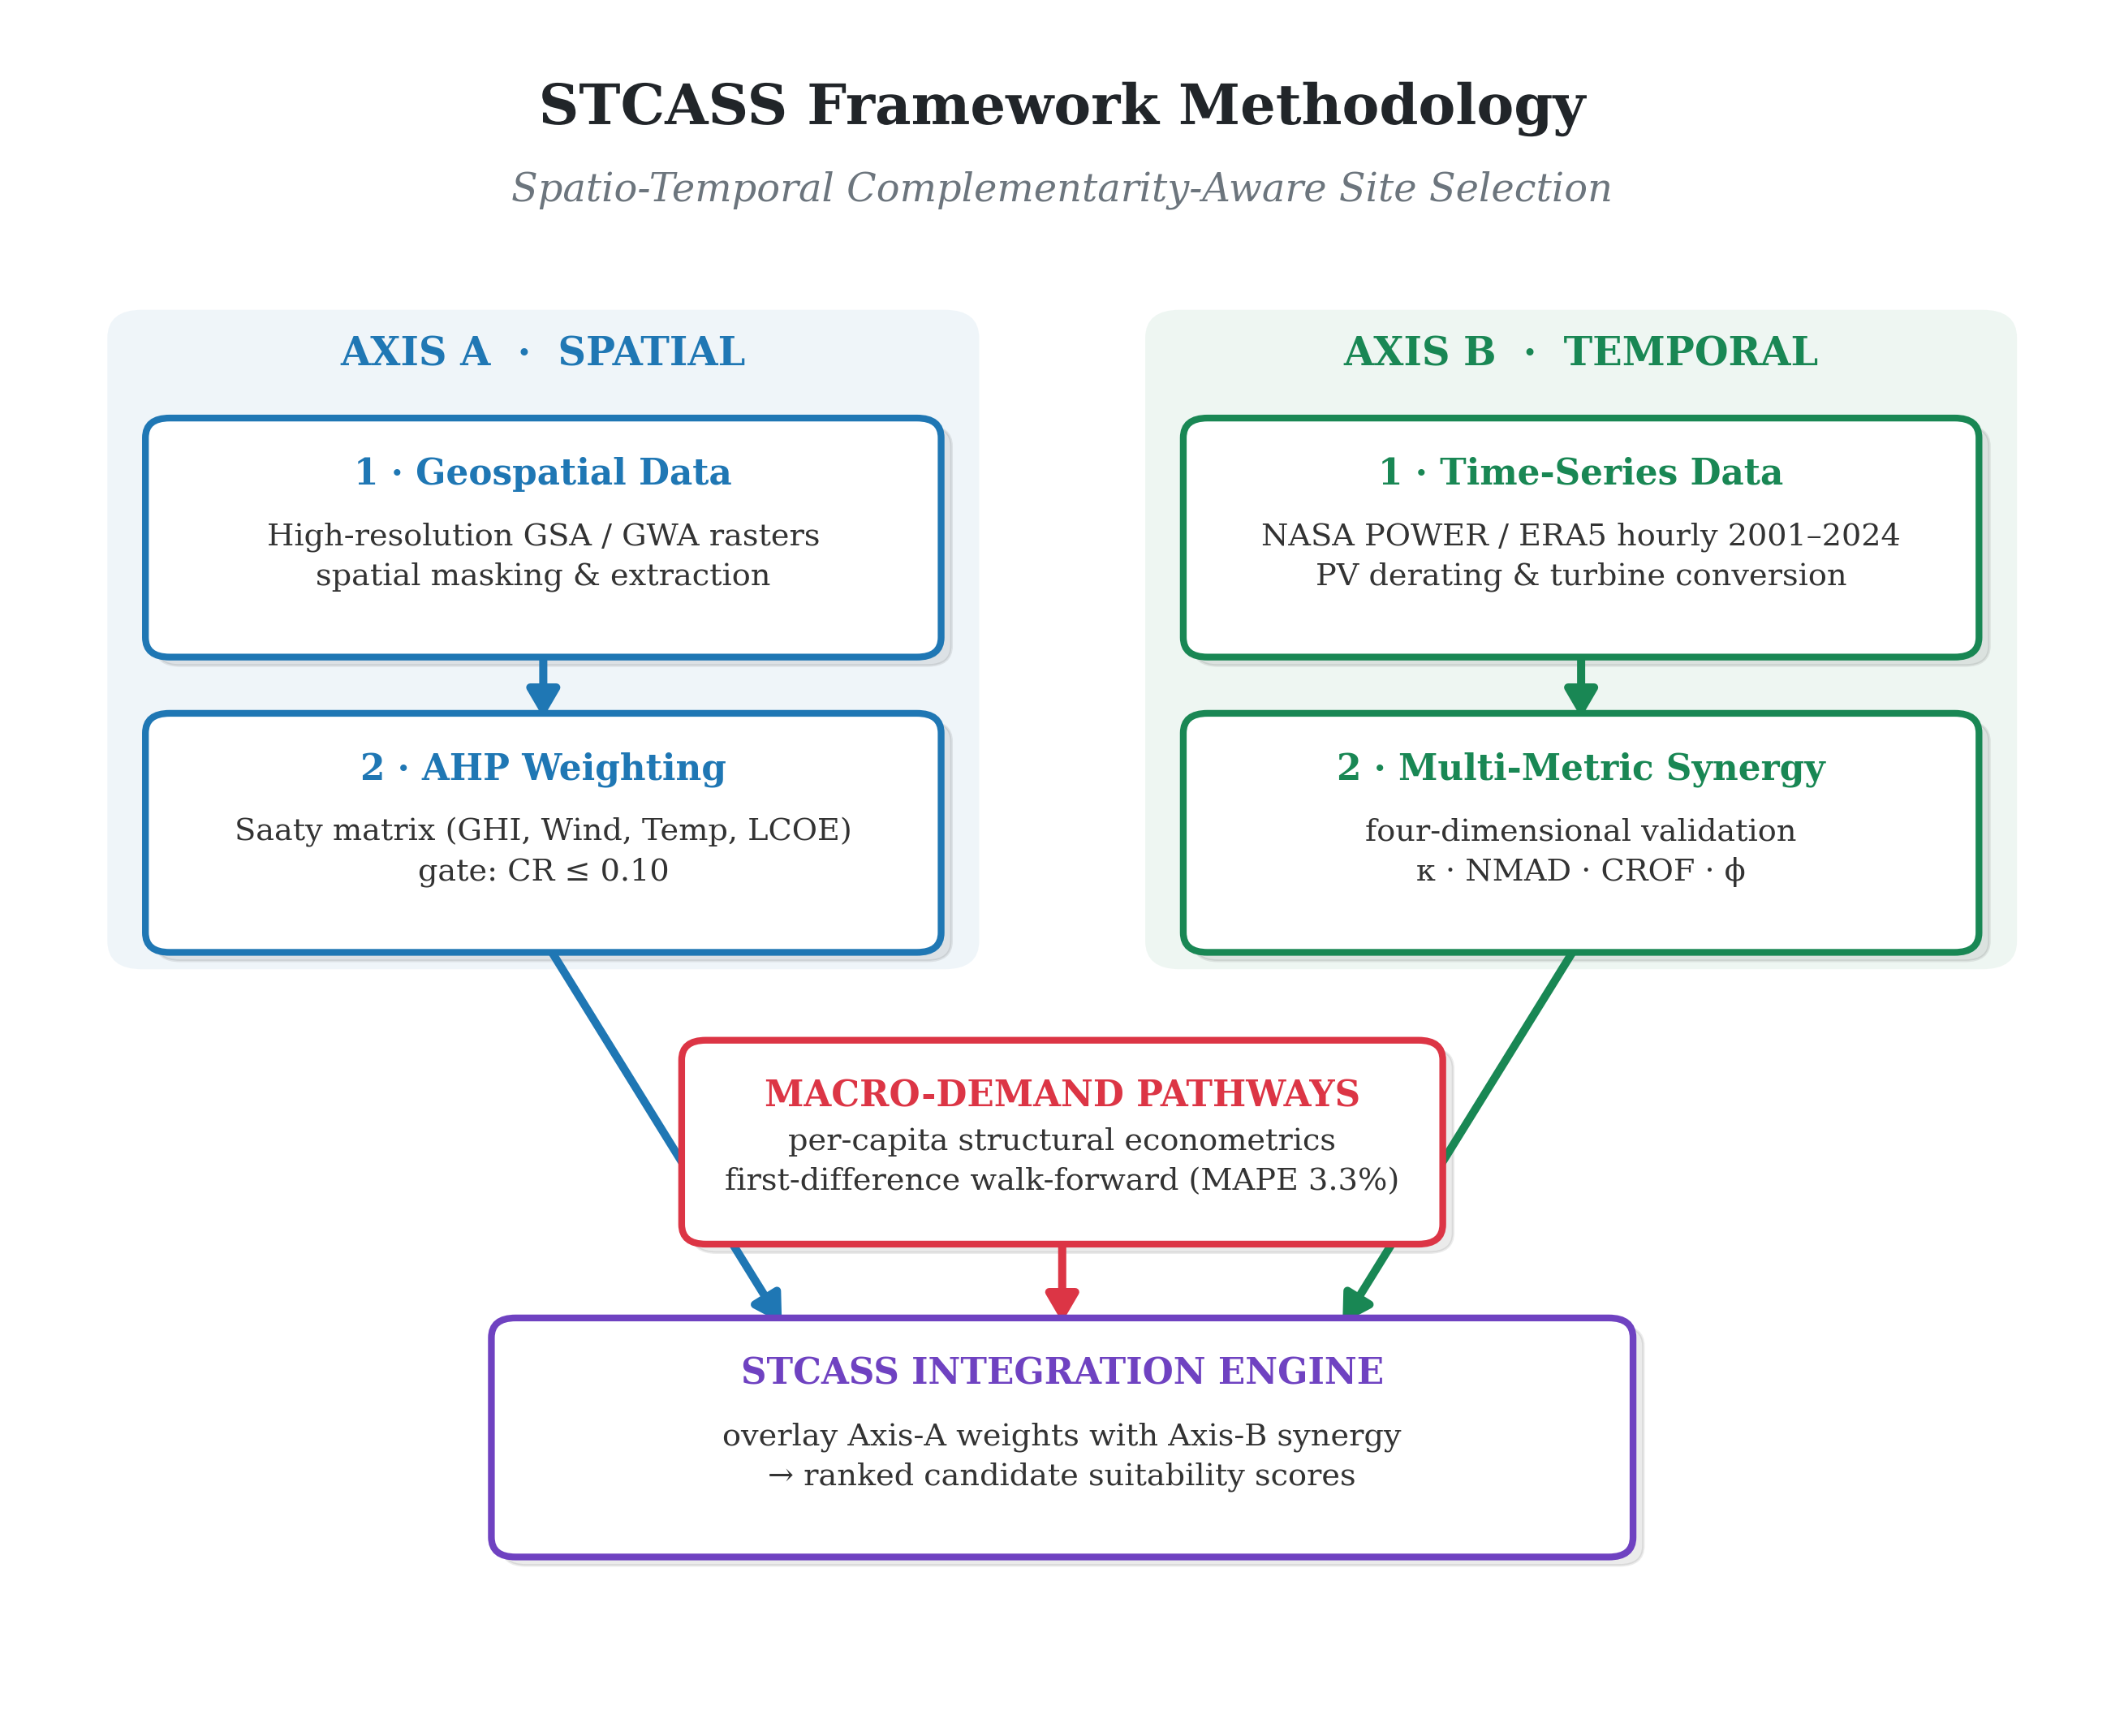

In [3]:
def figure_flowchart_pro():
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyBboxPatch
    import matplotlib.patheffects as pe

    # use the pipeline's _save if available, else a local fallback
    try:
        saver = _save
    except NameError:
        def saver(fig, name):
            fig.savefig(name, dpi=300, bbox_inches="tight"); print("  saved", name); return name

    fig, ax = plt.subplots(figsize=(11, 9), dpi=300)
    ax.set_xlim(0, 12); ax.set_ylim(0, 12); ax.axis("off")
    cA, cB, cC, cS = "#1f77b4", "#198754", "#dc3545", "#6f42c1"   # spatial, temporal, demand, synthesis

    def lane(xc, y0, y1, color, header):
        w = 5.0
        ax.add_patch(FancyBboxPatch((xc-w/2, y0), w, y1-y0,
            boxstyle="round,pad=0.02,rounding_size=0.20",
            facecolor=color, edgecolor="none", alpha=0.07, zorder=0))
        ax.text(xc, y1-0.30, header, ha="center", va="center",
            fontsize=11.5, fontweight="bold", color=color, zorder=1)

    def box(x, y, w, h, title, text, color):
        ax.add_patch(FancyBboxPatch((x-w/2+0.06, y-h/2-0.06), w, h,           # shadow
            boxstyle="round,pad=0.10,rounding_size=0.14", color="black", alpha=0.08, zorder=1))
        ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,                     # panel
            boxstyle="round,pad=0.10,rounding_size=0.14",
            linewidth=2, edgecolor=color, facecolor="white", zorder=2))
        ax.text(x, y+h/2-0.30, title, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color=color, zorder=3)
        ax.text(x, y-0.14, text, ha="center", va="center",
            fontsize=9.2, color="#333333", linespacing=1.45, zorder=3)

    def arrow(x1, y1, x2, y2, color="#6c757d"):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>,head_width=0.35,head_length=0.6",
            lw=2.4, color=color, shrinkA=2, shrinkB=2), zorder=1)

    # header
    t = ax.text(6, 11.4, "STCASS Framework Methodology", ha="center", va="center",
                fontsize=16.5, fontweight="bold", color="#212529")
    t.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])
    ax.text(6, 10.82, "Spatio-Temporal Complementarity-Aware Site Selection",
            ha="center", va="center", fontsize=11.5, color="#6c757d", style="italic")

    # grouped lanes
    lane(3, 5.30, 9.95, cA, "AXIS A  \u00b7  SPATIAL")
    lane(9, 5.30, 9.95, cB, "AXIS B  \u00b7  TEMPORAL")

    # Axis A (spatial)
    box(3, 8.35, 4.4, 1.5, "1 \u00b7 Geospatial Data",
        "High-resolution GSA / GWA rasters\nspatial masking & extraction", cA)
    box(3, 6.25, 4.4, 1.5, "2 \u00b7 AHP Weighting",
        "Saaty matrix (GHI, Wind, Temp, LCOE)\ngate: CR \u2264 0.10", cA)
    arrow(3, 7.58, 3, 7.02, cA)

    # Axis B (temporal)
    box(9, 8.35, 4.4, 1.5, "1 \u00b7 Time-Series Data",
        "NASA POWER / ERA5 hourly 2001\u20132024\nPV derating & turbine conversion", cB)
    box(9, 6.25, 4.4, 1.5, "2 \u00b7 Multi-Metric Synergy",
        "four-dimensional validation\n\u03ba \u00b7 NMAD \u00b7 CROF \u00b7 \u03d5", cB)
    arrow(9, 7.58, 9, 7.02, cB)

    # macro-demand stream
    box(6, 4.05, 4.2, 1.25, "MACRO-DEMAND PATHWAYS",
        "per-capita structural econometrics\nfirst-difference walk-forward (MAPE 3.3%)", cC)

    # synthesis + output
    box(6, 1.95, 6.4, 1.5, "STCASS INTEGRATION ENGINE",
        "overlay Axis-A weights with Axis-B synergy\n\u2192 ranked candidate suitability scores", cS)

    # three streams -> synthesis (routed to clear the demand box)
    arrow(3, 5.50, 4.4, 2.72, cA)
    arrow(9, 5.50, 7.6, 2.72, cB)
    arrow(6, 3.42, 6, 2.72, cC)

    return saver(fig, "Fig1_STCASS_Pro_Flowchart.png")

figure_flowchart_pro()